# Interpolation

In diesem Jupyter Notebook wird die Berechnung von Interpolationen mit Python vorgestellt.

Problemstellung: Gegeben ist eine Abtastfolge $(t_k, x_k)$ mit $k=0,1,2, .. N$. 
Es sollen sinnvoll Werte zwischen den Abtastzeitpunkten berechnet, interpoliert werden.

Auf folgenden Arten soll die Berechnung der Interpolation erfolgen:
- 'zero order hold' - Wert zwischen den Abtastpunkt konstant halten
- 'linear' - Interpolation durch deine Gerade, die die benachbarten Abtastpunkte miteinander verbindet
- 'cubic'  - Interpolation durch ein Polynom 3ter Ordnung


<hr style="border:2px solid gray"> </hr>
References

[scipy - interpolation](https://docs.scipy.org/doc/scipy/reference/tutorial/interpolate.html)

<hr style="border:2px solid gray"> </hr>
History
<br>
2026-06-07 ug V1.3
<hr style="border:2px solid gray"> </hr>

In [1]:
%matplotlib inline
#%matplotlib notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Erzeugen einer Beispiel-Abtastfolge

Wir erzeugen uns eine Beispiel-Abtastfolge $(t_k, x_k)$ mit $k=0,1,2, .. N$ und $N=11$.

In [3]:
t_org = np.linspace(0, 10, num=11, endpoint=True)
x_org = np.cos(-t_org**2/9.0)

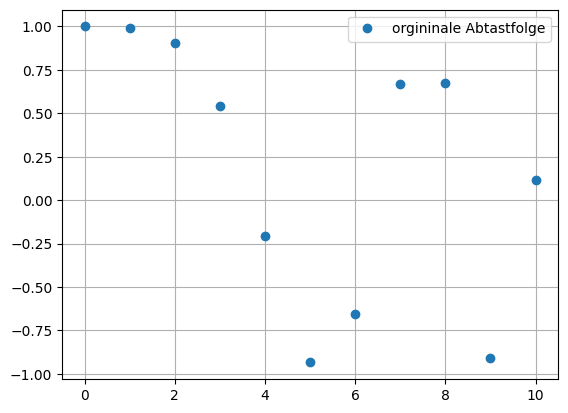

In [4]:
fig, ax = plt.subplots()
ax.plot(t_org,x_org,marker='o',linestyle='None',label='orgininale Abtastfolge')
ax.grid(True)
ax.legend()

## Eindimensionale lineare Interpolation (`np.interp()`)

Mit der Numpy-Funktion [`np.interp()`](https://numpy.org/doc/stable/reference/generated/numpy.interp.html) lassen sich Zwischenstellen anhand einer linearen Interpolation berechnen.

- erster Parameter - Skalar oder Array mit den zu berechnenden Abtastwerten
- zweiter und dritter Parameter - ursprüngliche Abtastfolge 

Zunächst nur eine Punkt interpolieren

In [5]:
t_neu = 3.5
x_neu = np.interp(t_neu, t_org, x_org)
x_neu

np.float64(0.167397792749991)

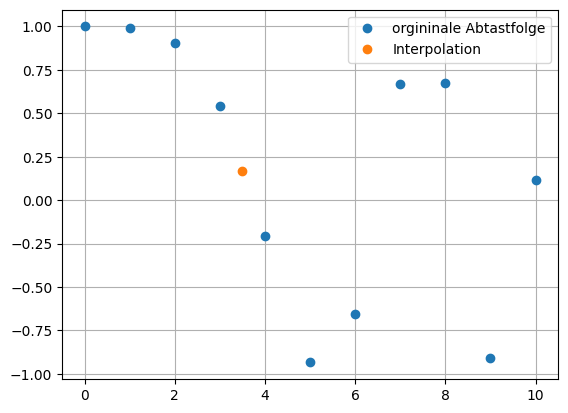

In [6]:
fig, ax = plt.subplots()
ax.plot(t_org,x_org,marker='o',linestyle='None',label='orgininale Abtastfolge')
ax.plot(t_neu,x_neu,marker='o',linestyle='None',label='Interpolation')
ax.grid(True)
ax.legend()


Mehrere Punkte gleichzeitig interpolieren

In [12]:
t_neu = np.arange(0.5,7.5)
x_neu = np.interp(t_neu, t_org, x_org)
x_neu

array([ 0.99691675,  0.94834159,  0.72157599,  0.16739779, -0.57002643,
       -0.79409488,  0.00737814])

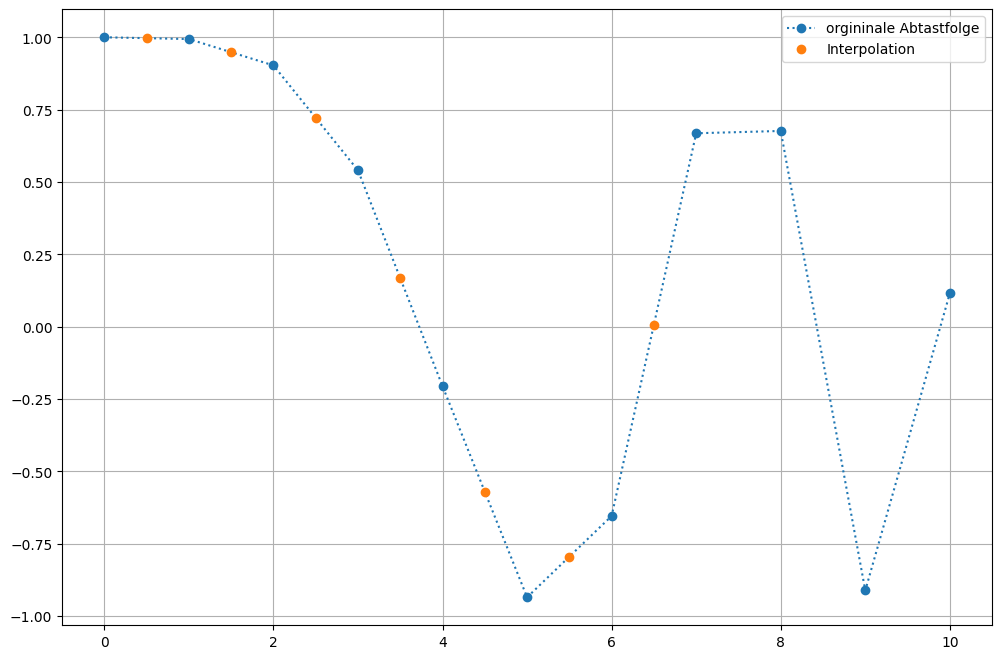

In [13]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(t_org,x_org,marker='o',linestyle=':',label='orgininale Abtastfolge')
ax.plot(t_neu,x_neu,marker='o',linestyle='None',label='Interpolation')
ax.grid(True)
ax.legend()

-----

## Interpolation (`scipy.interpolate.interp1d`)

Mit der Scipy-Funktion [`scipy.interpolate.interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html) lässt sich eine eindimensionale Funktion, z.B. in Abtastfolge auf verschieden Arten interpolieren.

In [14]:
from scipy.interpolate import interp1d

### lineare und kubische Interpolation
Mit Hilfe der originalen Folge wird jeweils ein Objekt erzeugt:

In [15]:
intp_linear = interp1d(t_org, x_org)                # lineare Interpolation
intp_cubic  = interp1d(t_org, x_org, kind='cubic')  # kubische Interpolation

Aufruf der Objekte wie eine Funktion:

In [16]:
t_neu = 3.5
intp_linear(t_neu)

array(0.16739779)

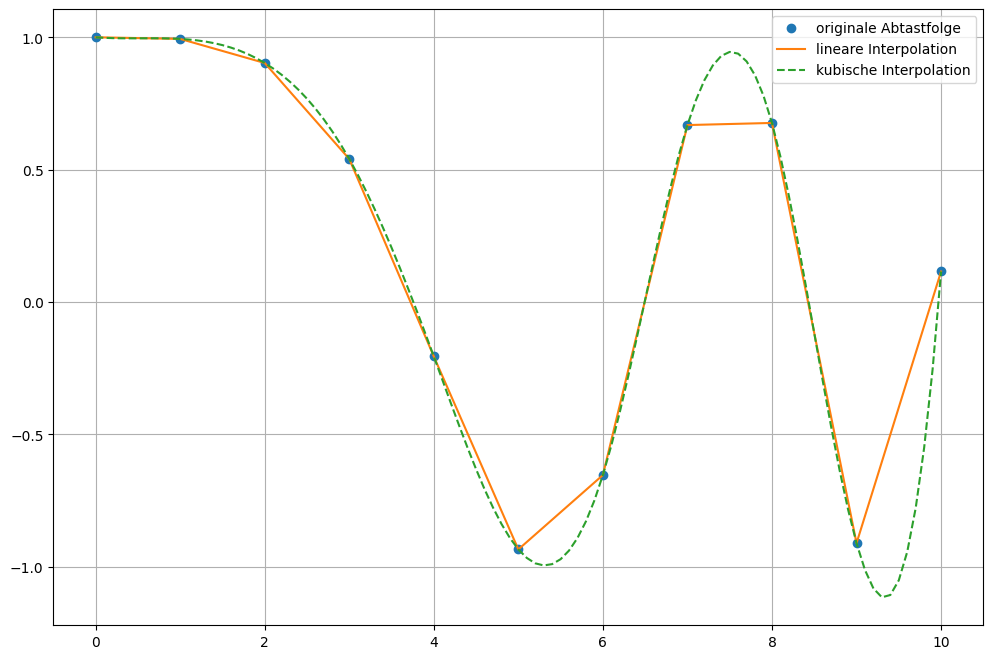

In [17]:
t_new = np.linspace(0, 10, num=101, endpoint=True)

fig, ax = plt.subplots(figsize=(12,8))

ax.plot(t_org, x_org, 'o', label= 'originale Abtastfolge')
ax.plot(t_new, intp_linear(t_new), '-',label='lineare Interpolation')
ax.plot(t_new, intp_cubic(t_new), '--',label='kubische Interpolation')
ax.legend()
ax.grid(True)


### konstante Halteglieder - zero order hold interpolation

Mit Hilfe der originalen Folge wird jeweils ein Objekt erzeugt:

In [18]:
intp_nearest = interp1d(t_org, x_org, kind='nearest')
intp_previous = interp1d(t_org, x_org, kind='previous')
intp_next = interp1d(t_org, x_org, kind='next')

In [19]:
t_neu = 3.5
print(f"x = {t_org[t_org<t_neu][-1]:.2f} .. {t_org[t_org>t_neu][0]:.2f}")
print(f"x = {x_org[t_org<t_neu][-1]:.2f} .. {x_org[t_org>t_neu][0]:.2f}")
print(f"intp_nearest({t_neu})  = {intp_nearest(t_neu):.2f}")
print(f"intp_previous({t_neu}) = {intp_previous(t_neu):.2f}")
print(f"intp_next({t_neu})     = {intp_next(t_neu):.2f}")

x = 3.00 .. 4.00
x = 0.54 .. -0.21
intp_nearest(3.5)  = 0.54
intp_previous(3.5) = 0.54
intp_next(3.5)     = -0.21


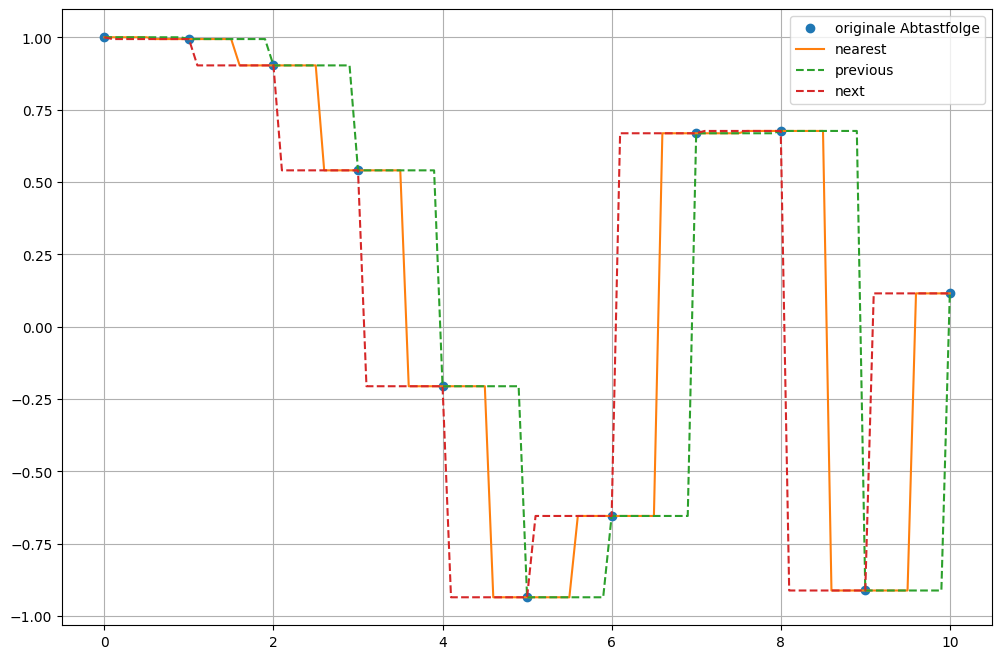

In [20]:
xnew = np.linspace(0, 10, num=1001, endpoint=True)

fig, ax = plt.subplots(figsize=(12,8))

ax.plot(t_org, x_org, 'o', label= 'originale Abtastfolge')
ax.plot(t_new, intp_nearest(t_new), '-',label='nearest')
ax.plot(t_new, intp_previous(t_new), '--',label='previous')
ax.plot(t_new, intp_next(t_new), '--',label='next')

ax.legend()
ax.grid(True)

<hr style="border:2px solid gray"> </hr>